In [ ]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt



In [2]:
eye = qt.qeye(2)

# common states
state_0 = qt.basis(2, 0)
state_1 = qt.basis(2, 1)
state_plus = (state_0 + state_1).unit()
state_minus = (state_0 - state_1).unit()

state_00 = qt.tensor(state_0, state_0)
state_01 = qt.tensor(state_0, state_1)
state_10 = qt.tensor(state_1, state_0)
state_11 = qt.tensor(state_1, state_1)
state_plus_plus = qt.tensor(state_plus, state_plus)

# define parameters
omega = 2.0

# a,b

In [3]:
H = omega * state_11 * state_11.dag()
psi_0 = state_plus_plus

T = np.pi / omega # ideal time for CZ gate
times = np.linspace(0, T, 1000) # times for evolution
result = qt.mesolve(H, psi_0, times, [])

psi_target = (state_00 + state_01 + state_10 - state_11).unit() # ideal CZ output state
fidelity = qt.fidelity(result.states[-1], psi_target)
print(result.states[-1])
print(fidelity)

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.49999999+0.00000000e+00j]
 [ 0.49999999+0.00000000e+00j]
 [ 0.49999999+0.00000000e+00j]
 [-0.50000004+2.53363859e-06j]]
0.9999999999975918


# d,e,f

In [4]:
xi = 0.05 * omega
H = omega * qt.tensor(state_11 * state_11.dag(), eye) + xi * qt.tensor(eye, state_11 * state_11.dag())
psi_0 = qt.tensor(state_plus_plus * state_plus_plus.dag(), eye / 2)

T = np.pi / omega
times = np.linspace(0, T, 1000)
result = qt.mesolve(H, psi_0, times, [])

rho_12 = result.states[-1].ptrace([0, 1])

fidelity = qt.fidelity(rho_12, psi_target)
print((1-fidelity) * 100)

0.15401551123258583


In [5]:
xi_values = np.linspace(-0.1 * omega, 0.1 * omega, 1000)
fidelities = []

for xi in xi_values:
    H = omega * qt.tensor(state_11 * state_11.dag(), eye) + xi * qt.tensor(eye, state_11 * state_11.dag())
    psi_0 = qt.tensor(state_plus_plus * state_plus_plus.dag(), eye / 2)
    
    result = qt.mesolve(H, psi_0, times, [])
    rho_12 = result.states[-1].ptrace([0, 1])
    
    fidelity = qt.fidelity(rho_12, psi_target)
    fidelities.append(fidelity)

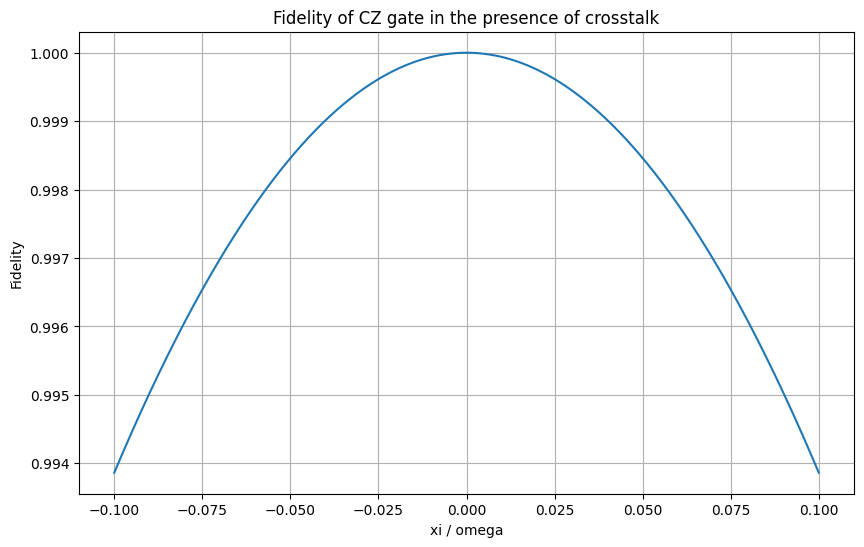

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(xi_values / omega, fidelities)
plt.xlabel('xi / omega')
plt.ylabel('Fidelity')
plt.title('Fidelity of CZ gate in the presence of crosstalk')
plt.grid()
plt.show()